# 02 — Exploratory Data Analysis (EDA)

> **Mục tiêu:** Khám phá đặc trưng ngôn ngữ, phân phối nhãn và tần suất từ vựng của tập dữ liệu ISOT. Đây là cơ sở quan trọng để xây dựng pipeline tiền xử lý và lựa chọn đặc trưng ở các bước tiếp theo.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")

## 1. Load Data & Basic Information

In [5]:
df = pd.read_csv('../data/preprocessed_isot_full.csv')
print("Dataset loaded successfully. Shape:", df.shape)
display(df.head())

Dataset loaded successfully. Shape: (38653, 3)


,full_text,processed_text,label
0,JUDGE JEANINE PIRRO DECLARES WAR On Hillary…Le...,judge jeanine pirro declares war hillary leake...,1
1,WATCH: Giuliani’s BIG LIE At Trump Rally Is J...,watch giuliani big lie trump rally jawdropping...,1
2,Republican House Speaker Ryan backs Trump afte...,republican house speaker ryan back trump long ...,0
3,Wikileaks: NSA Spied on UN Secretary-General a...,wikileaks nsa spied secretarygeneral world lea...,1
4,Freeing of hostages in Pakistan a 'positive si...,freeing hostage pakistan positive sign general...,0


In [6]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 38653 entries, 0 to 38652
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   full_text       38653 non-null  str  
 1   processed_text  38653 non-null  str  
 2   label           38653 non-null  int64
dtypes: int64(1), str(2)
memory usage: 906.1 KB


> [!NOTE]  
> Dataset dùng trong EDA này đã trải qua quá trình tiền xử lý ở Notebook 01, do đó dữ liệu đã sạch (không còn giá trị Null, trùng lặp hoặc các ký tự nhiễu).

In [7]:
print("\n--- Ví dụ mẫu Tin Thật (Real News) ---")
print(df[df['label'] == 0]['full_text'].iloc[0][:500] + "...")

print("\n--- Ví dụ mẫu Tin Giả (Fake News) ---")
print(df[df['label'] == 1]['full_text'].iloc[0][:500] + "...")


--- Ví dụ mẫu Tin Thật (Real News) ---
Republican House Speaker Ryan backs Trump after long courtship WASHINGTON (Reuters) - Paul Ryan, the top elected Republican, ended a long period of soul-searching and endorsed Donald Trump for president on Thursday, a step toward unifying party loyalists behind the insurgent candidate despite concerns about his candidacy. Ryan had been a high-profile holdout to supporting Trump for the Nov. 8 presidential election out of concern about the presumptive Republican nominee’s bellicose rhetoric and b...

--- Ví dụ mẫu Tin Giả (Fake News) ---
JUDGE JEANINE PIRRO DECLARES WAR On Hillary…Leaked E-Mails Prove The Election Was Rigged [Video] Judge Jeanine Pirro rips into  Crooked  Hillary for her collusion in rigging the election process so she would come out on top of Bernie Sanders: ...


## 2. Distribution of FAKE/REAL (Label Column)

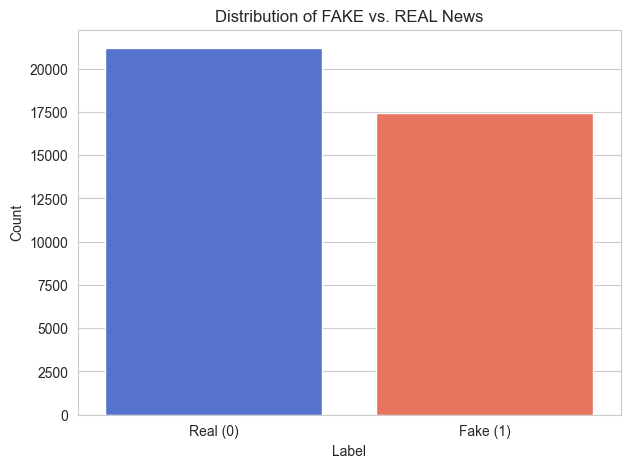

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='label', hue='label', palette={0: 'royalblue', 1: 'tomato'}, legend=False)
plt.xticks([0, 1], ['Real (0)', 'Fake (1)'])
plt.title('Distribution of FAKE vs. REAL News')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

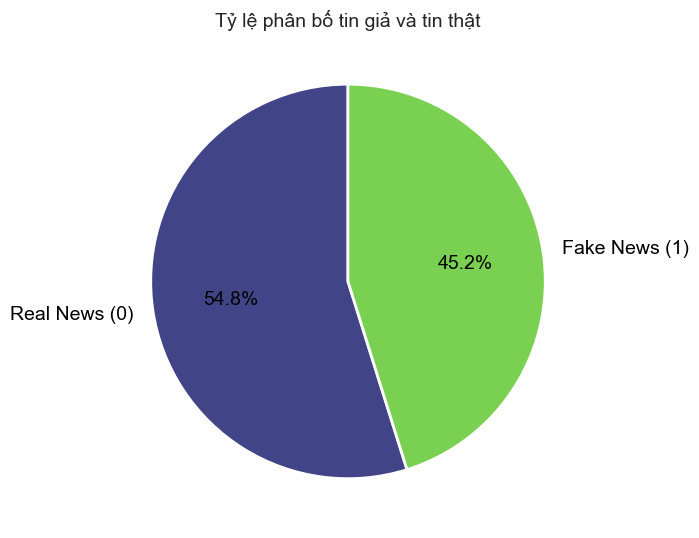

In [13]:
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 2))
plt.figure(figsize=(7,7))
df['label'].value_counts().plot.pie(
    labels=['Real News (0)', 'Fake News (1)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 14, 'color': 'black'},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)

plt.title('Tỷ lệ phân bố tin giả và tin thật', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

### 📊 Phân tích phân bố nhãn:
- **Tin thật (Real):** Chiếm khoảng **55%** tổng lượng mẫu.
- **Tin giả (Fake):** Chiếm khoảng **45%** tổng lượng mẫu.

> 
> Tập dữ liệu có tỷ lệ phân phối khá cân bằng (~55/45). Do đó, không xảy ra hiện tượng **mất cân bằng lớp (class imbalance)**. Chúng ta có thể tin tưởng sử dụng chỉ số **Accuracy** làm độ đo chính, kết hợp thêm **F1-Score (weighted)** để đánh giá mô hình một cách toàn diện.

## 3. Text Length Analysis

In [14]:
df["char_count"] = df["processed_text"].astype(str).apply(len)
df["word_count"] = df["processed_text"].astype(str).apply(
    lambda x: len(x.split())
)

In [15]:
df[["char_count", "word_count"]].describe()

,char_count,word_count
count,38653.000000,38653.000000
mean,1740.016402,234.597729
std,1339.523341,176.622753
min,40.000000,6.000000
25%,962.000000,131.000000
50%,1568.000000,213.000000
75%,2161.000000,292.000000
max,37869.000000,4810.000000


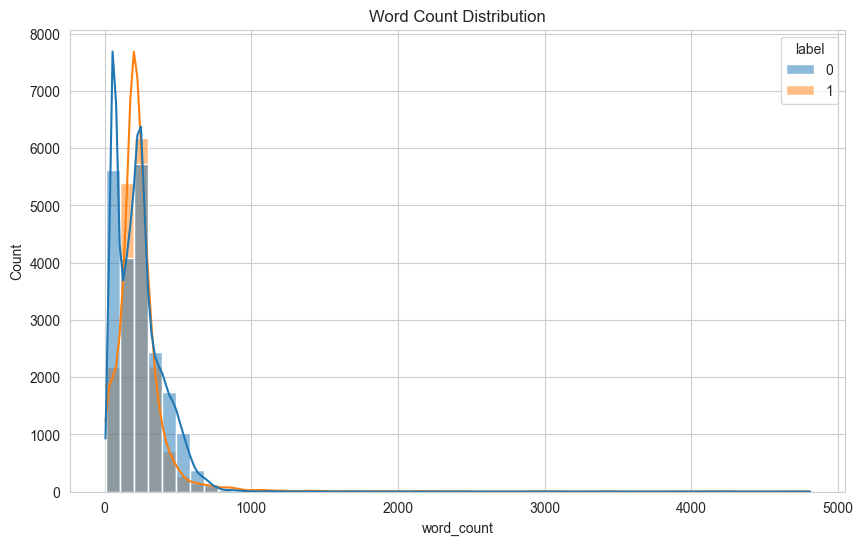

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="word_count",
    hue="label",
    bins=50,
    kde=True
)

plt.title("Word Count Distribution")
plt.show()

### 💡 Đặc điểm về độ dài văn bản (Số lượng từ)
- **Tin thật (Real News):** Độ dài phân phối rất tập trung, chủ yếu nằm trong khoảng **300 – 600 từ**. Điều này phản ánh cấu trúc biên tập tin tức chuẩn mực và nhất quán của các hãng tin chính thống.
- **Tin giả (Fake News):** Độ dài phân tán cực kỳ mạnh. Xuất hiện cả những bài viết rất ngắn (chỉ vài chục từ) lẫn những bài viết dài đột biến.

> 
> Sự khác biệt lớn về phân phối độ dài cho thấy **độ dài văn bản** là một thuộc tính có giá trị phân biệt tốt trong bài toán phát hiện tin giả.

## 4. Most Common Words

In [17]:
fake_text = " ".join(
    df[df["label"] == 1]["processed_text"].astype(str)
)
real_text = " ".join(
    df[df["label"] == 0]["processed_text"].astype(str)
)
fake_words = Counter(fake_text.split())
real_words = Counter(real_text.split())

In [18]:
fake_words.most_common(10)

[('trump', 71462),
 ('not', 35310),
 ('said', 23073),
 ('people', 21147),
 ('president', 20440),
 ('one', 18742),
 ('would', 18347),
 ('state', 16333),
 ('donald', 15624),
 ('republican', 14867)]

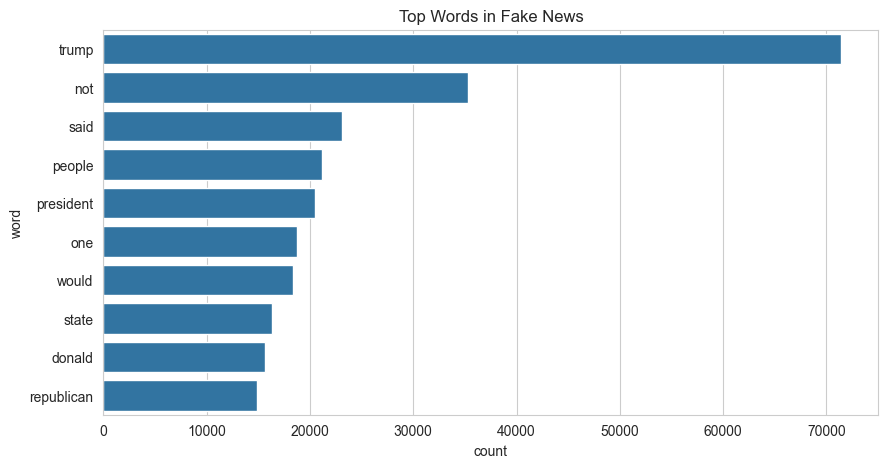

In [19]:
top_fake = pd.DataFrame(
    fake_words.most_common(10),
    columns=["word", "count"]
)

plt.figure(figsize=(10,5))
sns.barplot(data=top_fake, x="count", y="word")
plt.title("Top Words in Fake News")
plt.show()

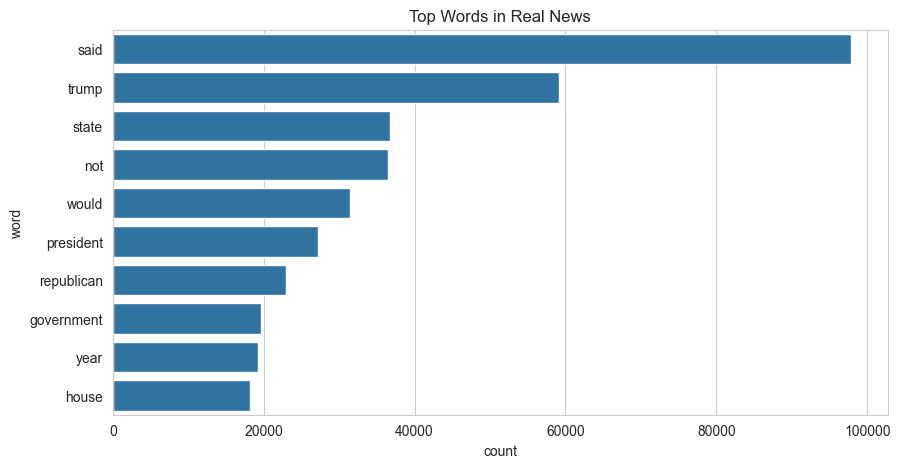

In [20]:
top_real = pd.DataFrame(
    real_words.most_common(10),
    columns=["word", "count"]
)

plt.figure(figsize=(10,5))
sns.barplot(data=top_real, x="count", y="word")

plt.title("Top Words in Real News")
plt.show()

### 🔤 Phân tích đặc trưng từ vựng đơn (Unigram)
- **Tin thật (Real News):** Xuất hiện tần suất cao các từ liên quan đến sự kiện, địa danh và phát ngôn chính thức như *reuters*, *president*, *said*, *state*, *washington*. Điều này thể hiện tính thời sự chính trị.
- **Tin giả (Fake News):** Thường xuất hiện các từ mang tính thu hút chú ý hoặc liên quan đến tranh cãi chính trị như *video*, *watch*, *just*, *hillary*, *obama*.

> 💡  
> Sự khác biệt rõ ràng về từ vựng củng cố giả thuyết rằng mô hình dựa trên tần suất từ (như **TF-IDF**) sẽ hoạt động hiệu quả cho bài toán này.

In [21]:
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words="english")

In [22]:
X_fake = vectorizer.fit_transform(
    df[df["label"] == 1]["processed_text"]
)

In [23]:
sum_words = X_fake.sum(axis=0)

words_freq = [
    (word, sum_words[0, idx])
    for word, idx in vectorizer.vocabulary_.items()
]

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

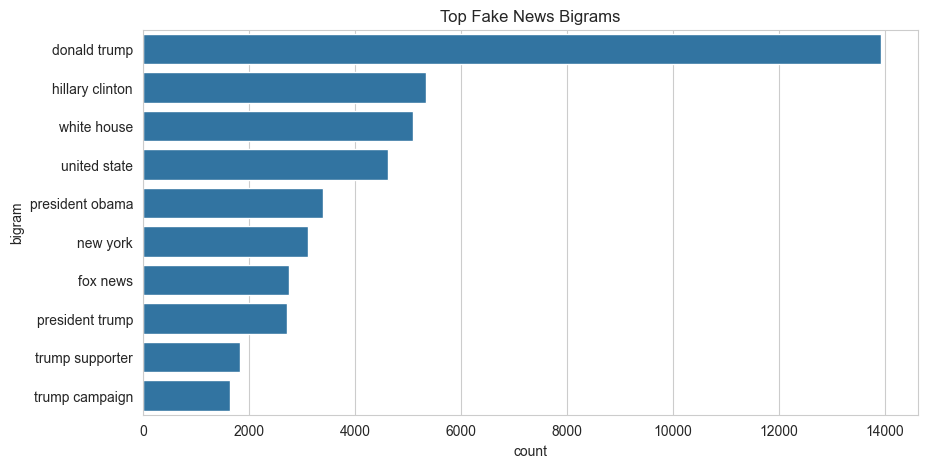

In [24]:
top_bigrams = pd.DataFrame(
    words_freq[:10],
    columns=["bigram", "count"]
)

plt.figure(figsize=(10,5))

sns.barplot(data=top_bigrams, x="count", y="bigram")

plt.title("Top Fake News Bigrams")
plt.show()

## 5. Word Cloud Generation

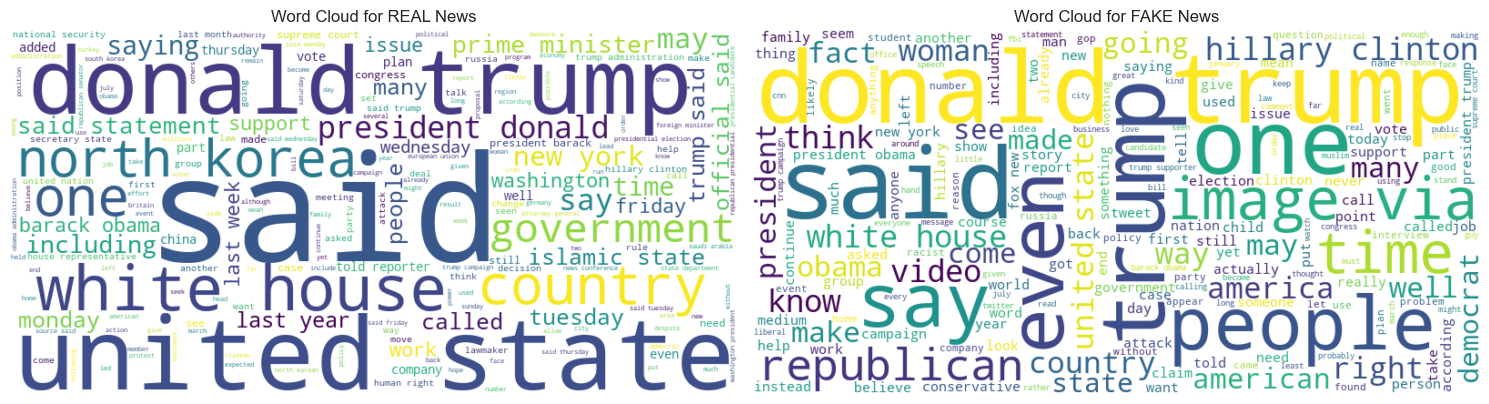

In [25]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)

wordcloud_real = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(real_text)

plt.imshow(wordcloud_real, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for REAL News')


# FAKE NEWS
plt.subplot(1, 2, 2)

wordcloud_fake = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(fake_text)

plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for FAKE News')

plt.tight_layout()
plt.show()

## 6. Top Unigrams & Bigrams

C:\Users\Nguyen Xuan\AppData\Local\Temp\ipykernel_20808\3171325715.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=ngram_df, palette='viridis')


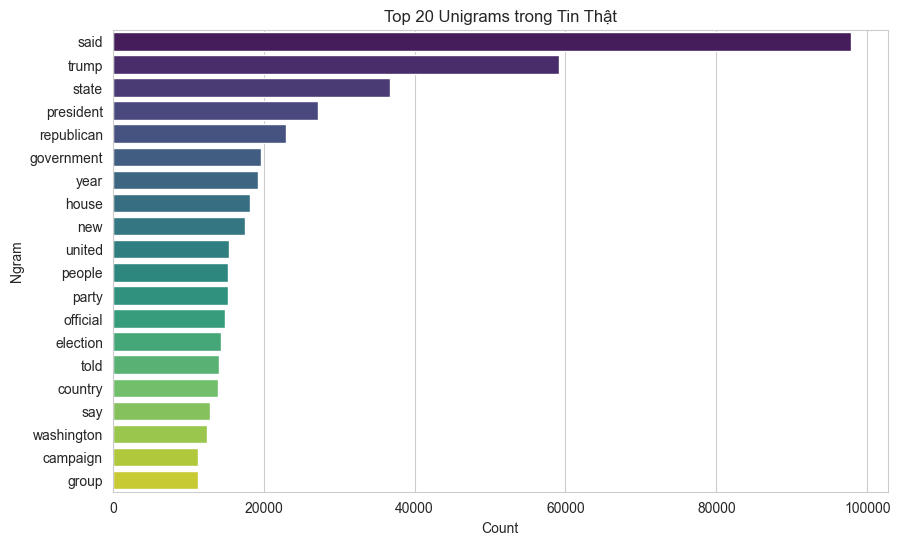

C:\Users\Nguyen Xuan\AppData\Local\Temp\ipykernel_20808\3171325715.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=ngram_df, palette='viridis')


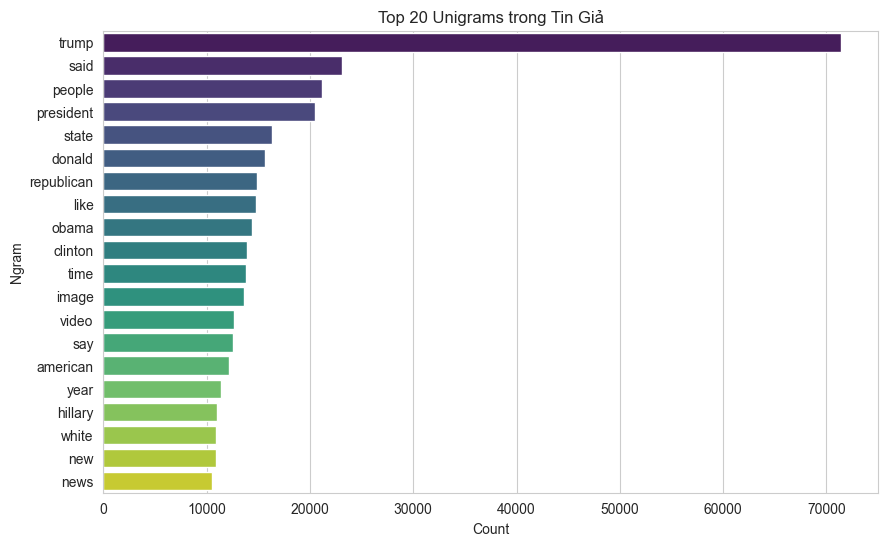

C:\Users\Nguyen Xuan\AppData\Local\Temp\ipykernel_20808\3171325715.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=ngram_df, palette='viridis')


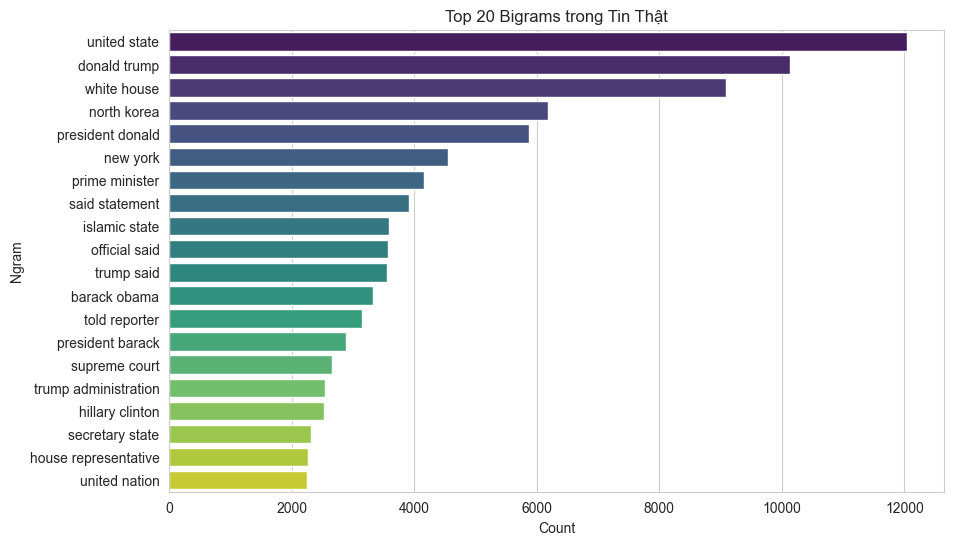

C:\Users\Nguyen Xuan\AppData\Local\Temp\ipykernel_20808\3171325715.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Ngram', data=ngram_df, palette='viridis')


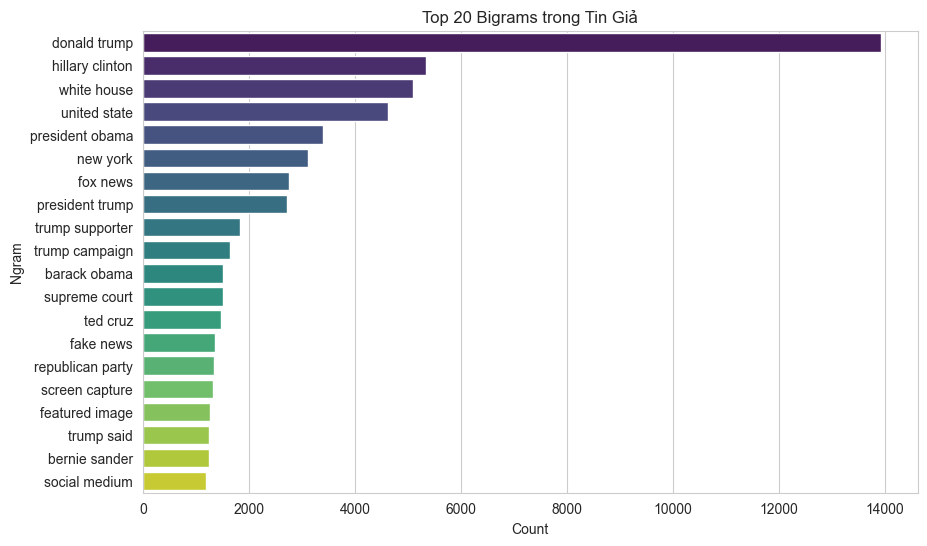

In [26]:
def plot_top_ngrams(text_series, title, ngram_range=(1, 1), top_n=20):
    # Dùng stop_words='english' để loại bỏ hoàn toàn các từ vô nghĩa còn sót lại
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(text_series)
    bag_of_words = vec.transform(text_series)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:top_n]

    ngram_df = pd.DataFrame(words_freq, columns=['Ngram', 'Count'])
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Count', y='Ngram', data=ngram_df, palette='viridis')
    plt.title(title)
    plt.show()

# Trích xuất dữ liệu theo từng lớp
real_corpus = df[df['label'] == 0]['processed_text'].astype(str)
fake_corpus = df[df['label'] == 1]['processed_text'].astype(str)

# Vẽ đồ thị Top 20 Unigrams (Từ đơn)
plot_top_ngrams(real_corpus, "Top 20 Unigrams trong Tin Thật", ngram_range=(1, 1))
plot_top_ngrams(fake_corpus, "Top 20 Unigrams trong Tin Giả", ngram_range=(1, 1))

# Vẽ đồ thị Top 20 Bigrams (Cụm 2 từ)
plot_top_ngrams(real_corpus, "Top 20 Bigrams trong Tin Thật", ngram_range=(2, 2))
plot_top_ngrams(fake_corpus, "Top 20 Bigrams trong Tin Giả", ngram_range=(2, 2))

### ☄ Đặc trưng ngữ cảnh nội dung qua n-grams
- **Unigrams & Bigrams** vẽ ra bức tranh rõ nét về sự khác biệt chủ đề:
  - **Tin thật:** Tập trung vào các thuật ngữ báo chí chính luận chuyên nghiệp (*said reuters*, *donald trump*, *white house*).
  - **Tin giả:** Tập trung vào các chủ đề giật gân, kêu gọi hành động hoặc bàn luận chính trị xã hội mang tính cảm xúc (*featured image*, *donald trump*, *hillary clinton*).

## 6. Sentiment Analysis with VADER

Sử dụng thư viện **VADER** (Valence Aware Dictionary and sEntiment Reasoner) để phân tích cảm xúc của văn bản. VADER sẽ trả về điểm cảm xúc tổng hợp (Compound score) trong khoảng $[-1, 1]$:
- Gần **1.0**: Rất tích cực (Highly Positive).
- Gần **-1.0**: Rất tiêu cực (Highly Negative).
- Gần **0.0**: Trung lập (Neutral).

In [28]:
!pip install vaderSentiment

     -------------------------------------- 126.0/126.0 kB 1.1 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Hàm tính toán điểm compound
def get_sentiment(text):
    return analyzer.polarity_scores(str(text))['compound']

# Lấy mẫu một phần dữ liệu nếu dataset quá lớn để xử lý nhanh hơn
df['sentiment_score'] = df['processed_text'].apply(get_sentiment)

In [30]:
df['sentiment_score']

0       -0.7845
1       -0.9943
2        0.9970
3       -0.2584
4        0.9885
          ...  
38648    0.9835
38649    0.5859
38650   -0.8876
38651   -0.9952
38652    0.1779
Name: sentiment_score, Length: 38653, dtype: float64

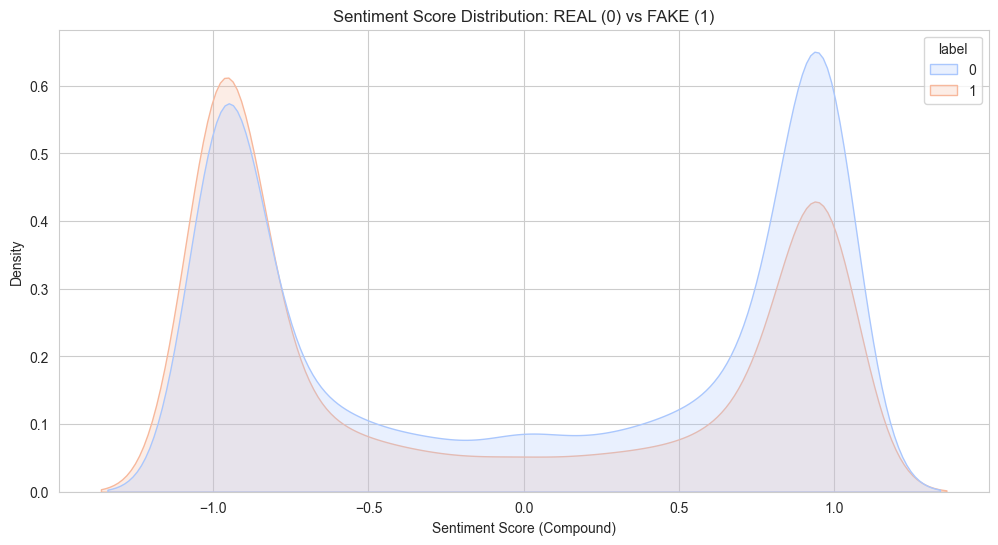

In [31]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x='sentiment_score', hue='label', fill=True, palette='coolwarm')
plt.title('Sentiment Score Distribution: REAL (0) vs FAKE (1)')
plt.xlabel('Sentiment Score (Compound)')
plt.ylabel('Density')
plt.show()

In [32]:
print("Thống kê điểm Sentiment theo nhãn:")
display(df.groupby('label')['sentiment_score'].describe())

Thống kê điểm Sentiment theo nhãn:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,21196.0,0.051129,0.833645,-0.9997,-0.9136,0.2175,0.9274,0.9998
1,17457.0,-0.128908,0.850652,-1.0000,-0.9691,-0.5122,0.8910,0.9999


### 📊 Nhận xét về phân phối cảm xúc (Sentiment Analysis)
- **Tin giả (Fake News):** Thường có xu hướng thiên về cảm xúc tiêu cực hoặc cực đoan (lệch nhiều về phía bên trái $-1.0$), phản ánh tính chất giật gân, kích động hoặc bôi nhọ.
- **Tin thật (Real News):** Phân phối tập trung mạnh xung quanh giá trị trung lập $0.0$, thể hiện phong cách đưa tin khách quan và trung lập của các hãng tin chính thống như Reuters.

> 
> Điểm số cảm xúc là một chiều thông tin bổ trợ đắc lực cho mô hình học máy bên cạnh đặc trưng từ vựng thuần túy.